# Normal-tissue SigFormer analysis

Full normal-tissue demonstration using bundled raw data and cache-first outputs for comparison methods.

The notebook is intentionally verbose: configuration, inference, visualization, and saving are kept in separate cells so that a user can inspect or rerun each stage independently.

In [1]:
from __future__ import annotations

import datetime as _dt
import os, re, sys, math, time, json, shutil, logging, warnings, subprocess
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from scipy.stats import pearsonr, spearmanr
from IPython.display import display

import SigFormer
from SigFormer.scripts import s04_Util_apply as analysis
from SigFormer.scripts.s06_wrapper import (
    CLASS_wrapper_MuSiCal,
    CLASS_wrapper_SigFormer,
    CLASS_wrapper_SigLASSO,
    CLASS_wrapper_SigProfilerAssignment,
    CLASS_wrapper_sig_tool_lib,
    CLASS_wrapper_sigfit,
)

MASTER_DIR = Path.cwd().resolve()
RESOURCE_DIR = Path(SigFormer.RESOURCE_DIR)

In [2]:
%matplotlib inline

os.environ.setdefault("PYTHONHASHSEED", "717")
torch.set_num_threads(int(os.environ.get("SIGFORMER_NUM_THREADS", "8")))

import logging, warnings
logging.disable(logging.INFO)
warnings.filterwarnings("ignore", category=FutureWarning)

pd.set_option("display.max_rows", 150)
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)
plt.rcParams.update({"pdf.fonttype": 42, "ps.fonttype": 42})

In [3]:
# Create a clean run directory from the bundled normal-tissue inputs and cached comparison-method results.

PATH_source = RESOURCE_DIR / 'demo_normal'
PATH_source_raw, PATH_source_ext, PATH_source_cac = (PATH_source / '0_raw', PATH_source / '1_external', PATH_source / '1_cached')
PATH_cohort = MASTER_DIR / 'run_normal'
PATH_cohort_raw, PATH_cohort_ext, PATH_cohort_cac = (PATH_cohort / '0_raw', PATH_cohort / '1_external', PATH_cohort / '1_cached')
PATH_cohort_hmz = PATH_cohort / '2_harmonized_results'
PATH_cohort_UMAP = PATH_cohort / '3_UMAP'
PATH_cohort_CLUS = PATH_cohort / '4_per_cluster'
PATH_cohort_REPL = PATH_cohort / '5_replacement_test'
PATH_cohort__OOC = PATH_cohort / '6_OOC'
shutil.copytree(PATH_source_raw, PATH_cohort_raw, dirs_exist_ok=True)
shutil.copytree(PATH_source_ext, PATH_cohort_ext, dirs_exist_ok=True)
shutil.copytree(PATH_source_cac, PATH_cohort_cac, dirs_exist_ok=True)
for path in [PATH_cohort_hmz, PATH_cohort_UMAP, PATH_cohort_CLUS, PATH_cohort_REPL, PATH_cohort__OOC]:
    analysis.ensure_dir(path)

In [4]:
# Analysis constants, UMAP settings, and all wrapper parameters are explicit in this cell.

RANDOM_STATE = 717
K_NEIGHBORS = 35
PARAM__UMAP = dict(metric='cosine', n_neighbors=K_NEIGHBORS, min_dist=0.3, spread=1.0, init='random', leiden_resolution=1.2, random_state=RANDOM_STATE)
R_ENV = None
PATH_model = RESOURCE_DIR / 'sigformer_v9_epoch_1600.pt'
PARAM_REFINE = {'hard_composition': 0.005, 'hard_count': 3, 'prior_strength': 12.0, 'max_rescue': 2,
                'candidate_top_k': 6, 'max_l1_change': 0.20, 'max_ood_change': 0.15, 'max_ood_increase': 0.005,
                'rescue_min_composition': 0.01, 'n_channel_folds': 4, 'normalized_effective_depth': 1000, 'random_state': 717, 'version': None,}
PARAM_SgF = dict(PATH_model=str(PATH_model), epoch=None, device=None, simplex='softmax', strict=False, refine=True, refinement_kwargs=PARAM_REFINE)
PARAM_Mus = dict(method='likelihood_bidirectional', thresh=0.001)
PARAM_SPA = dict(PATH_tmp=None, hg_ver='GRCh38', cos_ver=3.4)
PARAM_sft = dict(conda_env=R_ENV, work_dir=None, fail_soft=False, iter=1400, warmup=None, chains=3, cores=1, seed=19970717)
PARAM_sLS = dict(conda_env=R_ENV, work_dir=None, fail_soft=False, conf=0.1, adaptive=True, gamma=1, alpha_min=400, iter_max=None, sd_multiplier=1.0, elastic_net=False, normalize='none',)
PARAM_stl = dict(conda_env=R_ENV, work_dir=None, nmuts_threshold=300, pvalue_threshold=0.15, pvalue_method='normErrorSAD', nmuts_method='residualSSD', fail_soft=False,)
TAG_TO_NAME = {'SgF_raw': 'SigFormer raw',
                   'SgF': 'SigFormer',
                   'Mus': 'MuSiCal',
                   'SPA': 'SigProfilerAssignment',
                   'sft': 'sigfit',
                   'sLS': 'sigLASSO',
                   'stl': 'signature.tools.lib',}
SIG_COLORS = analysis.DEFAULT_SIGNATURE_COLORS.copy()
METHOD_COLORS = analysis.METHOD_COLORS.copy()

---

## 1. Input and all-method inference

In [5]:
# Load normal-tissue SBS96 counts, metadata, and the COSMIC v3.4 reference.

VEC_sub_ctx = analysis.VEC_sub_ctx
X_raw_prof = pd.read_csv(PATH_cohort_raw / 'x_normal_3nt.tsv', sep='\t', index_col=0).loc[:, VEC_sub_ctx]
M_smp_meta = pd.read_csv(PATH_cohort_raw / 'x_normal_ann.tsv', sep='\t', index_col=0)
keep = M_smp_meta['depth'] >= 200
X_raw_prof, M_smp_meta = (X_raw_prof.loc[keep], M_smp_meta.loc[keep])
X_raw_prof.to_csv(PATH_cohort_hmz / '02_input_profile_matrix.tsv', sep='\t')
M_smp_meta.to_csv(PATH_cohort_hmz / '04_per_sample_metadata.tsv', sep='\t')
print(f'{len(X_raw_prof):,}/{len(keep):,} retained after depth >= 200')

1,957/1,957 retained after depth >= 200


In [6]:
# No multiple ref versions, just COSMIC 3.4

R_cosmic34 = pd.read_csv(RESOURCE_DIR / 'r_COSMIC_v3.4_SBS_GRCh38.tsv', sep='\t', index_col=0).loc[:, VEC_sub_ctx]
R_cosmic34.to_csv(PATH_cohort_hmz / '01_reference_COSMIC_v3.4.tsv', sep='\t')

In [7]:
# Point external wrappers to run-specific temporary folders and define cache locations.

PARAM_SPA['PATH_tmp'] = str(PATH_cohort / '_tmp/SigProfilerAssignment')
PARAM_sft['work_dir'] = str(PATH_cohort / '_tmp/sigfit')
PARAM_sLS['work_dir'] = str(PATH_cohort / '_tmp/sigLASSO')
PARAM_stl['work_dir'] = str(PATH_cohort / '_tmp/signature_tools_lib')
CACHE_PATHS = {'Mus': PATH_cohort_cac / 'y_normal_Mus.tsv',
               'SPA': PATH_cohort_cac / 'y_normal_SPA.tsv',
               'sft': PATH_cohort_cac / 'y_normal_sft.tsv',
               'sLS': PATH_cohort_cac / 'y_normal_SLS.tsv',
               'stl': PATH_cohort_cac / 'y_normal_STL.tsv',}

In [ ]:
# Build one runner dictionary and run cache-first inference in 500-sample chunks.

model_SgF = CLASS_wrapper_SigFormer(**PARAM_SgF)
DICT_runner = {'SgF_raw': model_SgF.predict_raw,
                   'SgF': model_SgF,
                   'Mus': CLASS_wrapper_MuSiCal(**PARAM_Mus),
                   'SPA': CLASS_wrapper_SigProfilerAssignment(**PARAM_SPA),
                   'sft': CLASS_wrapper_sigfit(**PARAM_sft),
                   'sLS': CLASS_wrapper_SigLASSO(**PARAM_sLS),
                   'stl': CLASS_wrapper_sig_tool_lib(**PARAM_stl),}

DICT_res = analysis.run_methods(X_raw_prof, R_cosmic34, DICT_runner, cache_paths=CACHE_PATHS, df_refmask=None, chunk_size=500, method_names=TAG_TO_NAME, save_cache=True, verbose=True)
OUTPUT_FILE_NAMES = {'SigFormer raw': 'SigFormer_raw',
                         'SigFormer': 'SigFormer',
                           'MuSiCal': 'MuSiCal_refit',
             'SigProfilerAssignment': 'SigProfiler',
                            'sigfit': 'sigfit',
                          'sigLASSO': 'SigLASSO',
               'signature.tools.lib': 'sig.tool.lib',}
for method, result in DICT_res.items():
    result['compo'].to_csv(PATH_cohort_hmz / f'03_decomposition_{OUTPUT_FILE_NAMES[method]}.tsv', sep='\t')
if 'diagnostics' in DICT_res['SigFormer']:
    DICT_res['SigFormer']['diagnostics'].to_csv(PATH_cohort_hmz / '03_decomposition_SigFormer_refinement_diagnostics.tsv', sep='\t')

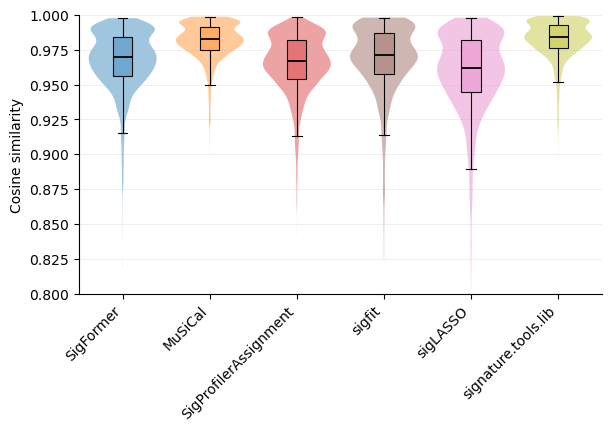

In [9]:
# Reconstruct SBS96 profiles and summarize method-level reconstruction quality.

METHOD_ORDER = ['SigFormer', 'MuSiCal', 'SigProfilerAssignment', 'sigfit', 'sigLASSO', 'signature.tools.lib']
method_order = [m for m in METHOD_ORDER if m in DICT_res]
cosine_results = {}
for method in method_order:
    recon = DICT_res[method]['recon']
    samples = X_raw_prof.index.intersection(recon.index, sort=False)
    channels = X_raw_prof.columns.intersection(recon.columns, sort=False)
    raw = X_raw_prof.loc[samples, channels].to_numpy(float)
    pred = recon.loc[samples, channels].to_numpy(float)
    denominator = np.linalg.norm(raw, axis=1) * np.linalg.norm(pred, axis=1)
    cosine_results[method] = pd.Series(np.divide(np.sum(raw * pred, axis=1), denominator, out=np.full(len(samples), np.nan), where=denominator > 0), index=samples, name=method)
fig, ax = plt.subplots(figsize=(6, 4.2), constrained_layout=True)
analysis.plot_recon_violin(cosine_results, method_order, METHOD_COLORS, ax=ax)
fig.savefig(PATH_cohort_hmz / 'reconstruction_cosine.pdf')
plt.show() ; plt.close(fig)

---

## 2. UMAP, clustering and geometry

In [10]:
# Fit Raw and method-specific UMAP/Leiden representations using one shared parameter set.

METHOD_TAGS = {'SigFormer raw': 'SgF_raw',
                   'SigFormer': 'SgF',
                     'MuSiCal': 'Mus',
       'SigProfilerAssignment': 'SPA',
                      'sigfit': 'sft',
                    'sigLASSO': 'sLS',
         'signature.tools.lib': 'stl',}
umap_meta = M_smp_meta.copy()
umap_results = {}
umap_results['Raw'] = analysis.run_umap_representation(X_raw_prof, umap_meta, 'Raw', PATH_cohort_UMAP, PARAM__UMAP)
for method, tag in METHOD_TAGS.items():
    if method not in DICT_res:
        continue
    print(f'UMAP: {method}')
    umap_results[method] = analysis.run_umap_representation(DICT_res[method]['compo'], umap_meta, tag, PATH_cohort_UMAP, PARAM__UMAP, reference_tag='Raw')
formal_cluster_col = 'Leiden_SgF_1.2'
umap_meta.to_csv(PATH_cohort_hmz / '04_per_sample_metadata.tsv', sep='\t')

UMAP: SigFormer raw
UMAP: SigFormer
UMAP: MuSiCal
UMAP: SigProfilerAssignment
UMAP: sigfit
UMAP: sigLASSO
UMAP: signature.tools.lib


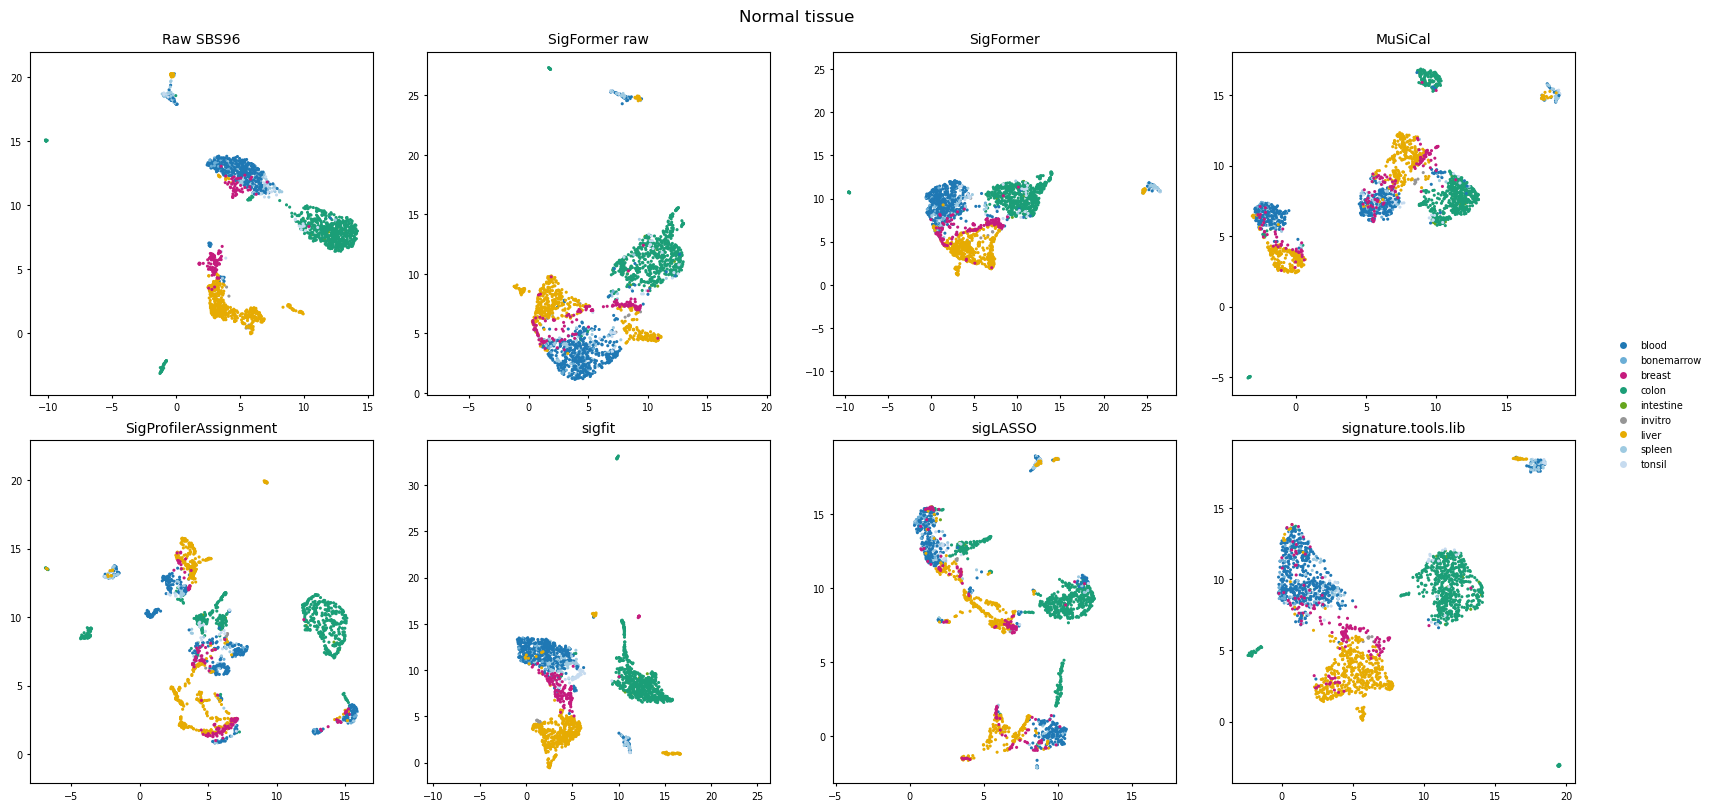

In [11]:
panels = [('Raw SBS96', 'Raw')] + [(method, tag) for method, tag in METHOD_TAGS.items() if method in DICT_res]
fig, axes = analysis.plot_umap_grid(umap_meta, panels, M_smp_meta['tissue'], categorical=True, palette=analysis.TISSUE_COLORS, title='Normal tissue')
plt.show() ; plt.close(fig)

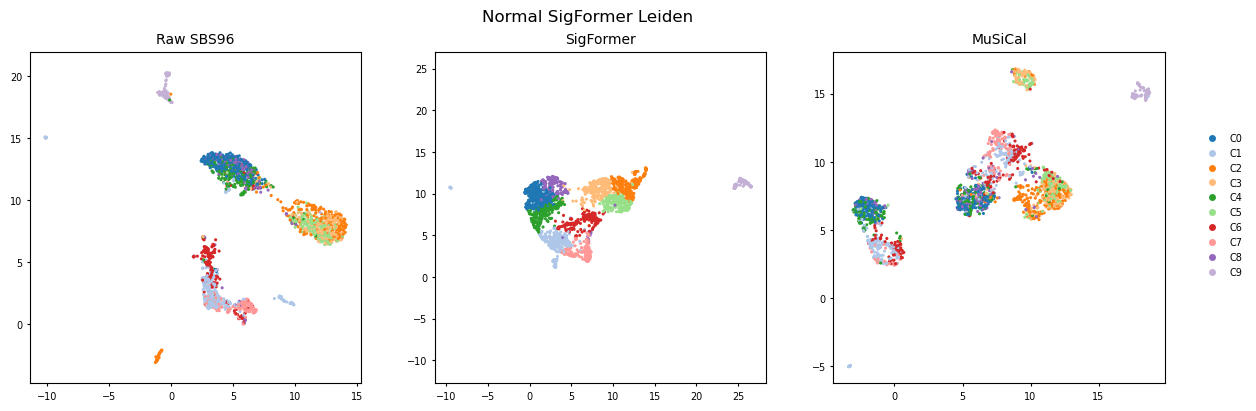

In [12]:
fig, axes = analysis.plot_umap_grid(umap_meta, [('Raw SBS96', 'Raw'), ('SigFormer', 'SgF'), ('MuSiCal', 'Mus')], umap_meta[formal_cluster_col], categorical=True, title='Normal SigFormer Leiden')
plt.show() ; plt.close(fig)

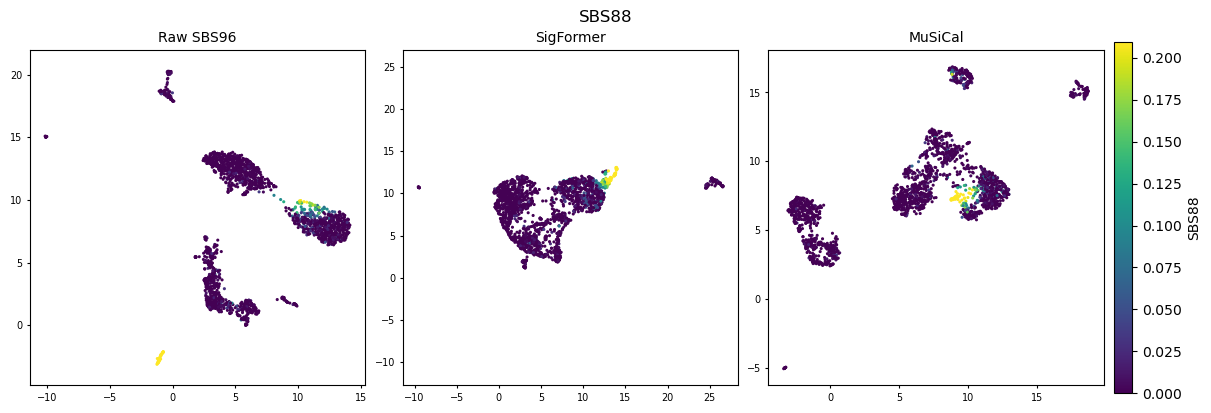

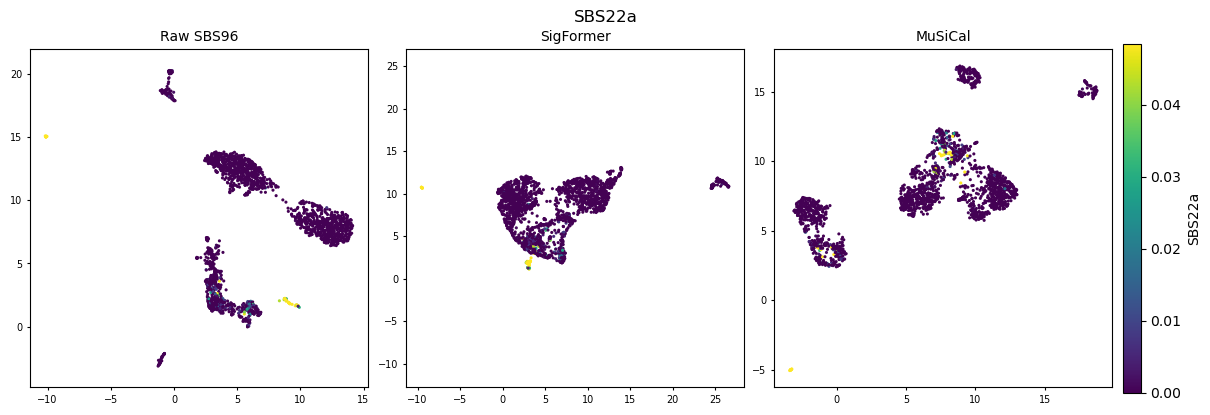

In [13]:
# Visualize tissue, cluster, and selected-signature views with explicit plotting helpers.
for sig in ['SBS88', 'SBS22a']:
    fig, axes = analysis.plot_umap_grid(umap_meta, [('Raw SBS96', 'Raw'), ('SigFormer', 'SgF'), ('MuSiCal', 'Mus')], DICT_res['SigFormer']['compo'].get(sig, 0), categorical=False, title=sig)
    plt.show() ; plt.close(fig)

In [14]:
# Quantify local/global geometry preservation independently of the UMAP visualization.

geometry = analysis.geometry_metrics(X_raw_prof, DICT_res, k=K_NEIGHBORS, max_pairs=50000, random_state=RANDOM_STATE, knn_graphs=None)
display(geometry)

,n_samples,pairwise_spearman,knn_jaccard,hellinger_neighbor_distance,median_active_signatures,median_effective_signatures
method,,,,,,
MuSiCal,1957,0.545538,0.118450,0.176821,12.0,6.211901
SigProfilerAssignment,1957,0.578394,0.114219,0.179869,4.0,2.859561
sigfit,1957,0.762637,0.224056,0.168275,28.0,26.297553
sigLASSO,1957,0.458559,0.104858,0.182652,5.0,2.895672
signature.tools.lib,1957,0.741604,0.195279,0.164485,19.0,10.859087
SigFormer raw,1957,0.752853,0.198851,0.166537,8.0,3.401566
SigFormer,1957,0.752587,0.193851,0.166914,9.0,3.514129


---

## 3. Per-cluster dotplots and stacked compositions

,0,1,2,3,4,5
method,SigFormer,MuSiCal,SigProfilerAssignment,sigfit,sigLASSO,signature.tools.lib
n,293,293,293,293,293,293
displayed_mass,0.895213,0.846009,0.982354,0.511091,0.959784,0.772217


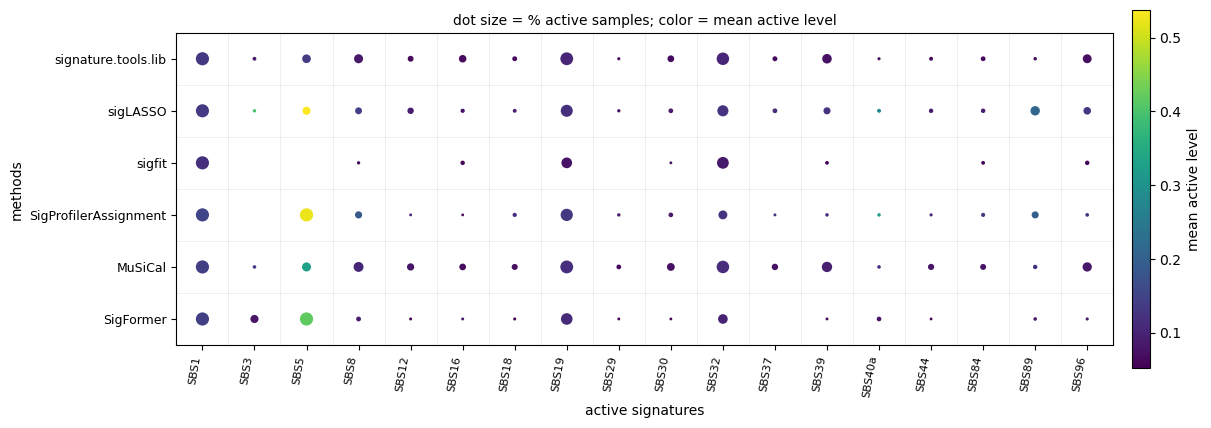

Stackbar config: sort=hclust | {'mode': 'hclust-average-cosine-OLO', 'source': 'SigFormer'}
Stackbar samples: total=293, shown=80, max_samples=80, subset=even
Stackbar signatures pass filter=18 | natural order: ['SBS1', 'SBS3', 'SBS5', 'SBS8', 'SBS12', 'SBS16', 'SBS18', 'SBS19', 'SBS29', 'SBS30', 'SBS32', 'SBS37', 'SBS39', 'SBS40a', 'SBS44', 'SBS84', 'SBS89', 'SBS96']
Stackbar signatures avg desc: [('SBS5', 0.2272), ('SBS1', 0.1361), ('SBS19', 0.0959), ('SBS32', 0.0809), ('SBS8', 0.0373), ('SBS89', 0.0318), ('SBS39', 0.0293), ('SBS96', 0.0276), ('SBS16', 0.0175), ('SBS30', 0.0161), ('SBS12', 0.0144), ('SBS3', 0.0128), ('SBS84', 0.0124), ('SBS18', 0.011), ('SBS37', 0.0106), ('SBS40a', 0.0099), ('SBS44', 0.0084), ('SBS29', 0.0056)]


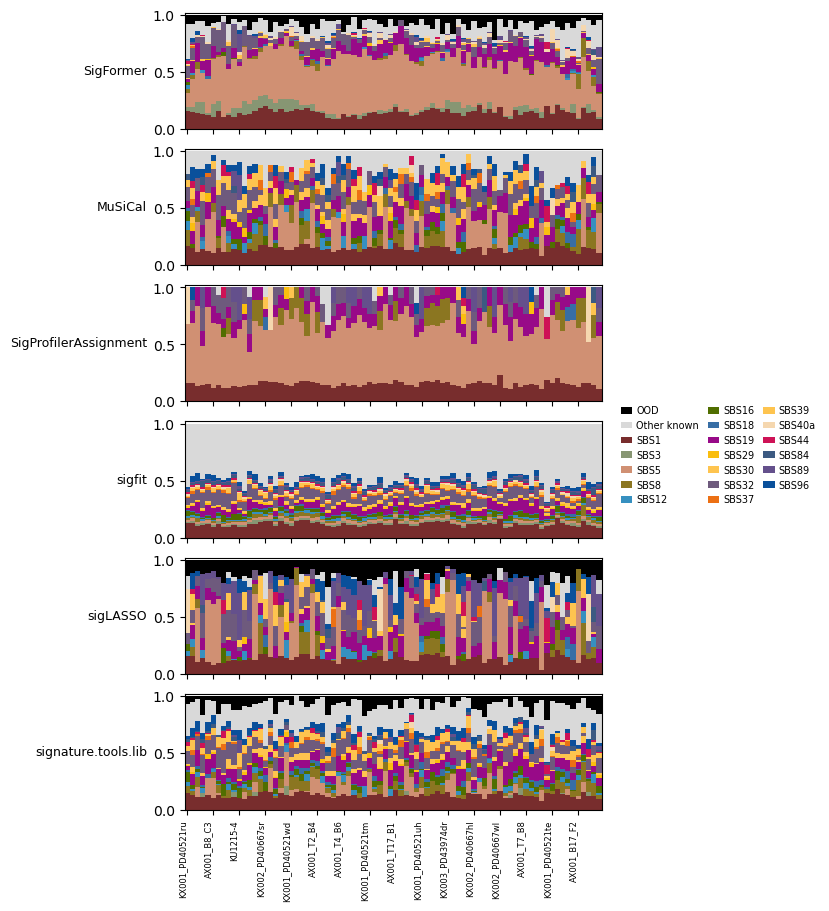

,0,1,2,3,4,5
method,SigFormer,MuSiCal,SigProfilerAssignment,sigfit,sigLASSO,signature.tools.lib
n,284,284,284,284,284,284
displayed_mass,0.917706,0.818734,0.973063,0.52204,0.953535,0.739158


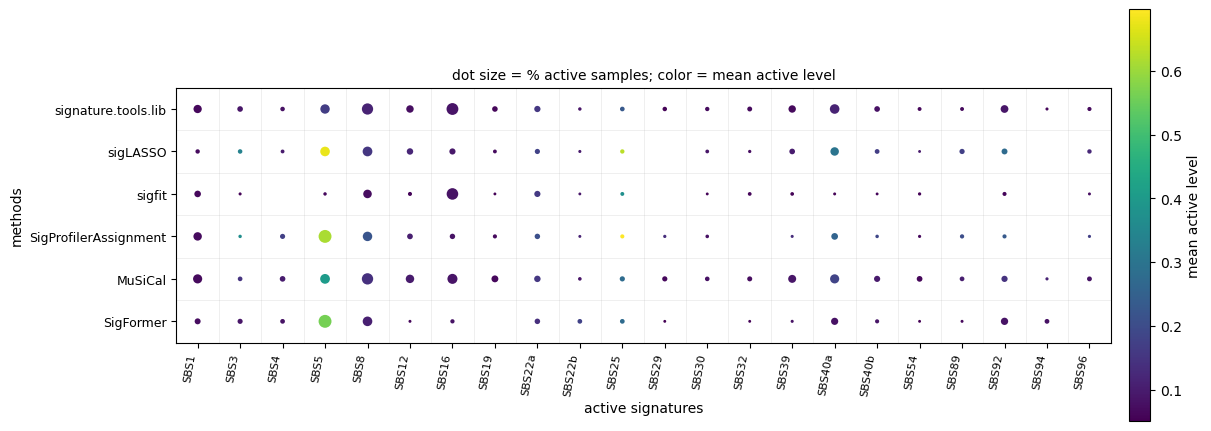

Stackbar config: sort=hclust | {'mode': 'hclust-average-cosine-OLO', 'source': 'SigFormer'}
Stackbar samples: total=284, shown=80, max_samples=80, subset=even
Stackbar signatures pass filter=22 | natural order: ['SBS1', 'SBS3', 'SBS4', 'SBS5', 'SBS8', 'SBS12', 'SBS16', 'SBS19', 'SBS22a', 'SBS22b', 'SBS25', 'SBS29', 'SBS30', 'SBS32', 'SBS39', 'SBS40a', 'SBS40b', 'SBS54', 'SBS89', 'SBS92', 'SBS94', 'SBS96']
Stackbar signatures avg desc: [('SBS5', 0.2988), ('SBS8', 0.0813), ('SBS40a', 0.0625), ('SBS16', 0.0409), ('SBS1', 0.0353), ('SBS25', 0.0331), ('SBS22a', 0.0305), ('SBS92', 0.0299), ('SBS12', 0.0237), ('SBS39', 0.0184), ('SBS3', 0.0176), ('SBS40b', 0.0144), ('SBS4', 0.0136), ('SBS19', 0.0128), ('SBS89', 0.012), ('SBS54', 0.0113), ('SBS32', 0.01), ('SBS96', 0.0089), ('SBS29', 0.0084), ('SBS30', 0.007), ('SBS22b', 0.006), ('SBS94', 0.0052)]


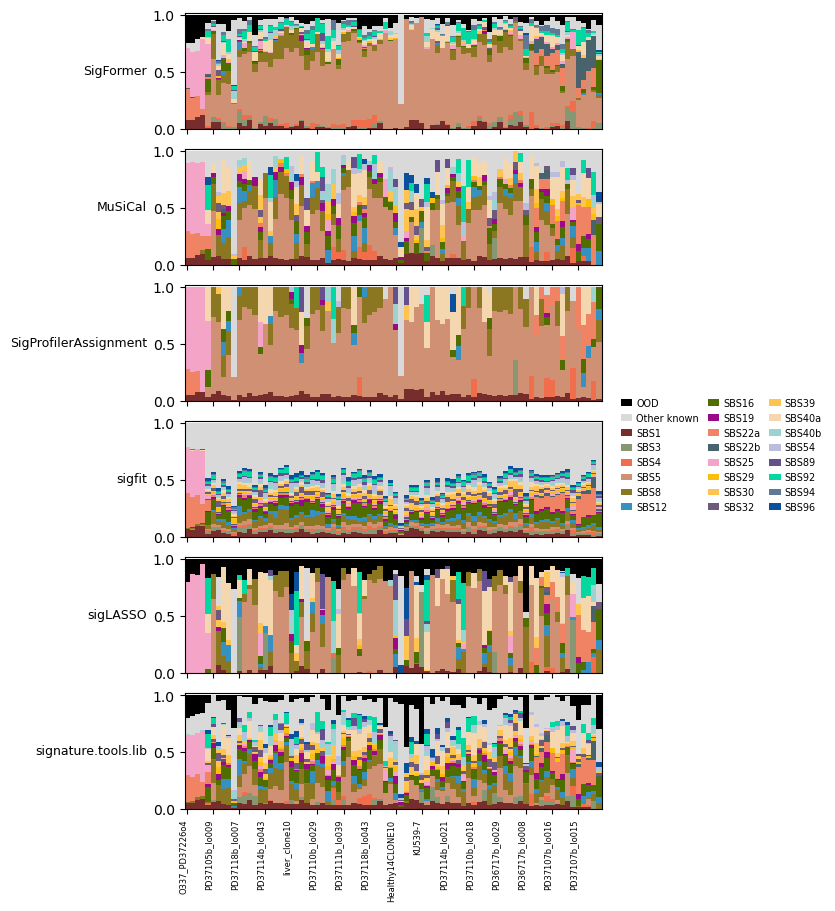

In [15]:
# Produce per-cluster dotplots and stacked signature compositions.

cluster_labels = sorted(umap_meta[formal_cluster_col].dropna().astype(str).unique(), key=analysis.sig_natkey)
CLUSTER_METHODS = [m for m in METHOD_ORDER if m in DICT_res]
max_smp, min_smp_frac, min_sig_expo = (80, 0.07, 0.05)
PARAM_dot = dict( min_sample_frac=min_smp_frac, min_weight=min_sig_expo, size_lim=(4, 90), cmap='viridis', size_by='pct_active', color_by='avg_active', size_range=(0, 1), show_grid=True,)
PARAM_bar = dict( min_sample_frac=min_smp_frac, min_weight=min_sig_expo, sort='hclust', hclust_tag='SigFormer', max_samples=max_smp, sample_subset='even', use_aligned_umap=True, xtick_every=5, xtick_rotation=90, xtick_fontsize=6, legend_ncol=3, size_sig_legend=7, ood_key='ood', verbose=True,)

for cluster in cluster_labels[:2]:
    loc = umap_meta.index[umap_meta[formal_cluster_col].astype(str).eq(cluster)]
    outdir = analysis.ensure_dir(PATH_cohort_CLUS / cluster)
    M_smp_meta.loc[loc, 'tissue'].value_counts().rename('n').to_frame().to_csv(outdir / 'top_tissue.tsv', sep='\t')
    
    ### dot plot
    fig, ax = plt.subplots(figsize=(12, 4.2), constrained_layout=True)
    dot = analysis.plot_cluster_dotplot(ax, DICT_res, loc, methods=CLUSTER_METHODS, **PARAM_dot)
    dot.to_csv(outdir / f'{cluster}_dotplot_data.tsv', sep='\t', index=False)
    fig.savefig(outdir / f'{cluster}_dotplot.pdf')
    plt.show() ; plt.close(fig)
    
    ### signature stacked barplot
    fig, axes = plt.subplots(len(CLUSTER_METHODS), 1, figsize=(6, max(8, 1.5 * len(CLUSTER_METHODS))), sharex=True, constrained_layout=True)
    stack = analysis.plot_cluster_stackbar(axes, DICT_res, umap_meta, loc, methods=CLUSTER_METHODS, sig_colors=SIG_COLORS, **PARAM_bar)
    fig.savefig(outdir / f'{cluster}_stacked_bar.pdf')
    plt.show() ; plt.close(fig)

---

## 4. Normal background continuum

No notebook-local function definitions. The clustering/downsampling/stack plotting use the same shared helpers as other datasets.

In [16]:
# Identify background-enriched samples and define biologically interpretable process families.

BACKGROUND = ['SBS1', 'SBS5', 'SBS40a']
FEATURE_FAMILIES = {
    'AID': ['SBS9', 'SBS85'],
    'APOBEC': ['SBS2', 'SBS13'],
    'tobacco_PAH': ['SBS4', 'SBS92'],
    'aristolochic_acid': ['SBS22a', 'SBS22b'],
    'colibactin': ['SBS88'],
    'SBS89': ['SBS89'],
    'therapy': ['SBS31', 'SBS35'],
    'SBS32': ['SBS32'],
    'SBS17': ['SBS17a', 'SBS17b'],
}
TISSUE_ORDER = ['liver', 'breast_normal', 'bonemarrow', 'blood', 'spleen', 'breast_lesion', 'breast_cancer', 'intestine', 'tonsil', 'colon']
SECTION_COLORS = {
    'liver': '#e6ab02',
    'breast_normal': '#4daf4a',
    'bonemarrow': '#6baed6',
    'blood': '#1f78b4',
    'spleen': '#9ecae1',
    'breast_lesion': '#ff7f00',
    'breast_cancer': '#984ea3',
    'intestine': '#66a61e',
    'tonsil': '#c6dbef',
    'colon': '#1b9e77',
}
SECTION_LABELS = {
    'liver': 'liver',
    'breast_normal': 'breast\nnormal',
    'bonemarrow': 'bone\nmarrow',
    'blood': 'blood',
    'spleen': 'spleen',
    'breast_lesion': 'breast\nlesion',
    'breast_cancer': 'breast\ncancer',
    'intestine': 'intestine',
    'tonsil': 'tonsil',
    'colon': 'colon',
}
Y = DICT_res['SigFormer']['compo'].reindex(umap_meta.index).fillna(0)
OOD = (1 - Y.sum(1)).clip(0, 1)
family = pd.DataFrame({k: Y.reindex(columns=v, fill_value=0).sum(1) for k, v in FEATURE_FAMILIES.items()}, index=Y.index)
non_bg_max = Y.drop(columns=[c for c in BACKGROUND if c in Y], errors='ignore').max(1)
clean = ~family.max(1).ge(0.05) & non_bg_max.lt(0.15) & OOD.lt(0.35) & Y.reindex(columns=BACKGROUND, fill_value=0).sum(1).gt(0)
mc = umap_meta.loc[clean].copy()
mc['OOD'] = OOD.loc[clean]
mc['breast_status'] = mc['cancer'].where(mc['tissue'].eq('breast'))
Yc = Y.loc[clean].copy()
Yc['OOD'] = OOD.loc[clean]
visible = [s for s in Y.columns if (Yc[s] > 0.05).mean() >= 0.05]
for sig in BACKGROUND:
    if sig in Y and sig not in visible:
        visible.append(sig)
visible = sorted(visible, key=analysis.sig_natkey)

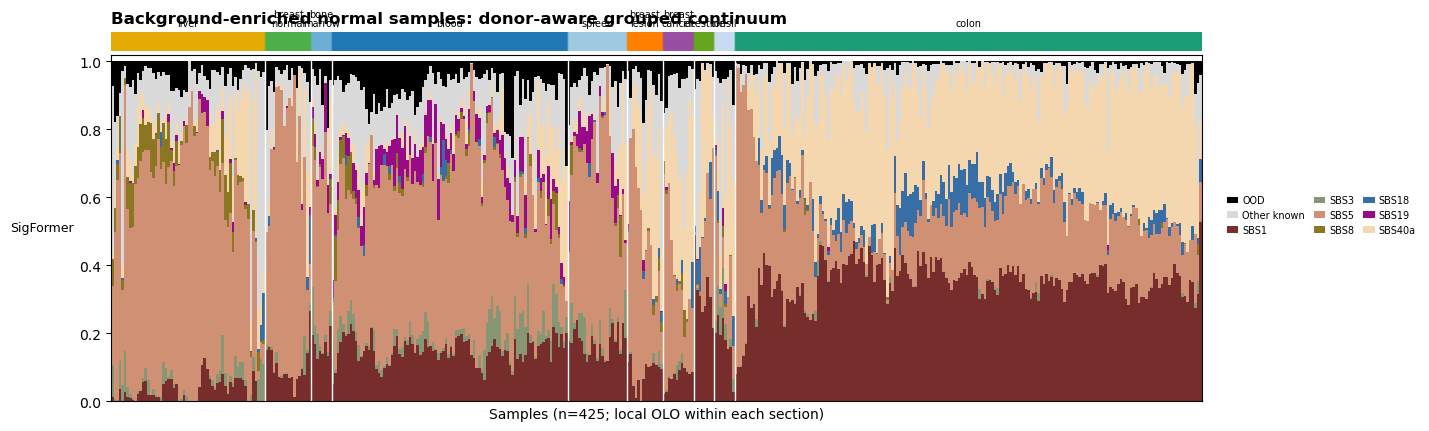

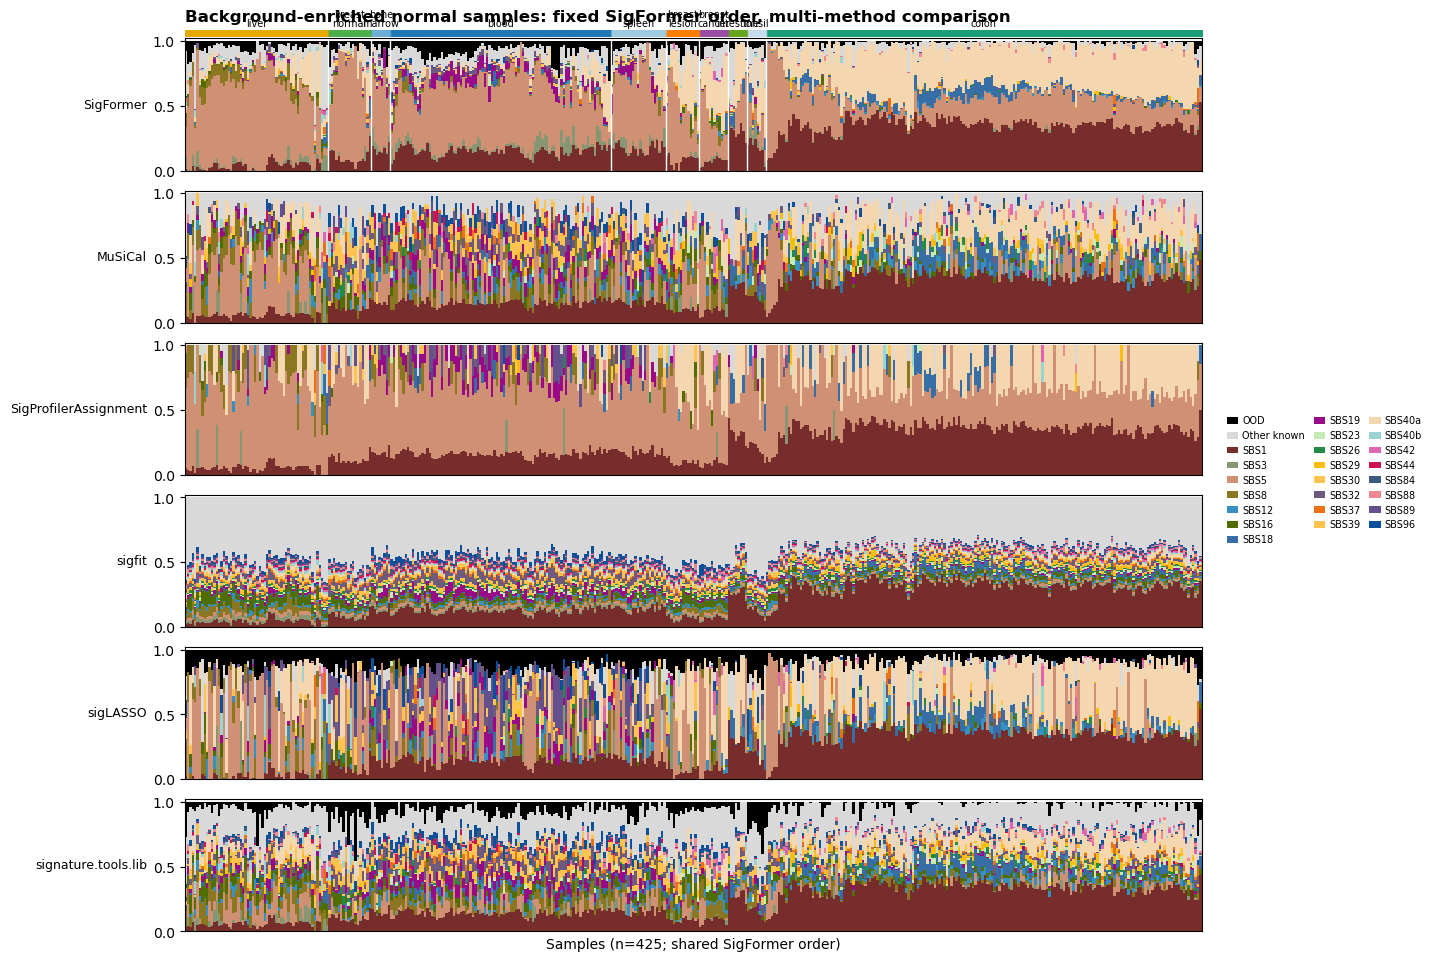

In [17]:
# Build donor/tissue-section continuums and a fixed-order multi-method comparison.

mc2 = mc.copy()
mc2['section'] = mc2['tissue']
for status in ['normal', 'lesion', 'cancer']:
    mc2.loc[mc2['tissue'].eq('breast') & mc2['breast_status'].eq(status), 'section'] = f'breast_{status}'
mc2 = mc2.loc[mc2['section'].isin(TISSUE_ORDER)]
Y2 = Yc.loc[mc2.index]
section_order = []
for section in TISSUE_ORDER:
    idx = mc2.index[mc2['section'].eq(section)]
    if len(idx) == 0:
        continue
    loc_order, _ = analysis.stack_hclust_order({'SigFormer': {'compo': Y2}}, idx, visible + ['OOD'], hclust_tag='SigFormer', anchor='SBS40a')
    n = min(max(8, int(round(420 * len(idx) / len(mc2)))), len(loc_order))
    section_order.extend(analysis.stack_thin(loc_order, n, 'even'))
fig, ax = plt.subplots(figsize=(12, 4.2), constrained_layout=True)
SIGFORMER_SECTION = {'SigFormer': {'compo': Y2.drop(columns='OOD'), 'ood': Y2['OOD']}}
analysis.plot_cluster_stackbar([ax], SIGFORMER_SECTION, mc2, section_order, methods=['SigFormer'], sort='input', max_samples=None, sig_colors=SIG_COLORS, sigs=visible, section_values=mc2['section'], section_colors=SECTION_COLORS, section_labels=SECTION_LABELS, verbose=False)
ax.set_title('Background-enriched normal samples: donor-aware grouped continuum', loc='left', weight='bold')
ax.set_xlabel(f'Samples (n={len(section_order)}; local OLO within each section)')
fig.savefig(PATH_cohort_CLUS / '03_background_continuum_grouped_by_tissue.pdf')
plt.show() ; plt.close(fig)
CONTINUUM_METHODS = [m for m in METHOD_ORDER if m in DICT_res]
visible_multi = set(BACKGROUND)
for method in CONTINUUM_METHODS:
    compo = DICT_res[method]['compo'].reindex(section_order).fillna(0)
    visible_multi.update(compo.columns[compo.gt(0.05).mean().ge(0.05)])
visible_multi = sorted(visible_multi - {'OOD', 'Other known'}, key=analysis.sig_natkey)
fig, axes = plt.subplots(len(CONTINUUM_METHODS), 1, figsize=(12, max(4.2, 1.45 * len(CONTINUUM_METHODS) + 0.8)), sharex=True, constrained_layout=True)
analysis.plot_cluster_stackbar(axes, DICT_res, mc2, section_order, methods=CONTINUUM_METHODS, sort='input', max_samples=None, sig_colors=SIG_COLORS, sigs=visible_multi, section_values=mc2['section'], section_colors=SECTION_COLORS, section_labels=SECTION_LABELS, verbose=False)
axes[0].set_title('Background-enriched normal samples: fixed SigFormer order, multi-method comparison', loc='left', weight='bold')
axes[-1].set_xlabel(f'Samples (n={len(section_order)}; shared SigFormer order)')
fig.savefig(PATH_cohort_CLUS / '04_background_continuum_multimethod_fixed_SigFormer_order.pdf')
plt.show() ; plt.close(fig)

---

## 5. Selected tissue/process stacked bars

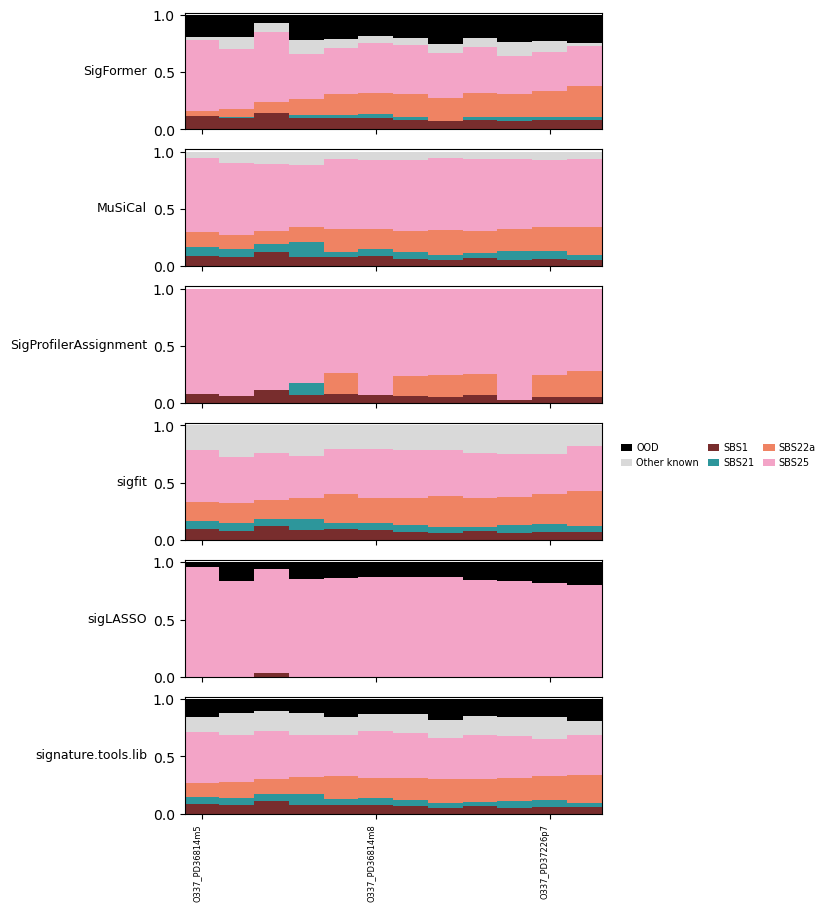

,selection,n_selected,n_shown,selection_rule
0,O337,12,12,sample ID contains O337


In [18]:
# Plot selected tissue/process subsets using the same shared stackbar helper.

selected_dir = analysis.ensure_dir(PATH_cohort_CLUS / 'selected_tissues_and_processes')
selected_methods = [m for m in METHOD_ORDER if m in DICT_res]
Y_selected = DICT_res['SigFormer']['compo']
selections = {
    'O337': umap_meta.index[umap_meta.index.astype(str).str.contains('O337')],
}
selection_rules = {'O337': 'sample ID contains O337'}
manifest = []
for label, loc in selections.items():
    loc = pd.Index(loc).intersection(umap_meta.index, sort=False)
    if len(loc) == 0: continue
    fig, axes = plt.subplots(len(selected_methods), 1, figsize=(6, max(8, 1.5 * len(selected_methods))), sharex=True, constrained_layout=True)
    SELECTED_STACK_CONFIG = {'min_sample_frac': 0.07, 'min_weight': 0.05, 'sort': 'hclust', 'hclust_tag': 'SigFormer',
                             'max_samples': 100, 'sample_subset': 'even', 'use_aligned_umap': True, 'xtick_every': 5,
                             'xtick_rotation': 90, 'xtick_fontsize': 6, 'legend_ncol': 3, 'size_sig_legend': 7,
                             'ood_key': 'ood', 'verbose': False,}
    stack = analysis.plot_cluster_stackbar(axes, DICT_res, umap_meta, loc, methods=selected_methods, sig_colors=SIG_COLORS, **SELECTED_STACK_CONFIG)
    fig.savefig(selected_dir / f'{label}_all_methods_stacked_bar.pdf')
    plt.show() ; plt.close(fig)
    pd.Series(stack['shown_order'], name='sample_id').to_csv(selected_dir / f'{label}_shown_order.tsv', sep='\t', index=False)
    manifest.append({'selection': label, 'n_selected': len(loc), 'n_shown': len(stack['shown_order']), 'selection_rule': selection_rules[label]})
pd.DataFrame(manifest).to_csv(selected_dir / 'selected_stackbar_manifest.tsv', sep='\t', index=False)
display(pd.DataFrame(manifest))

---

## 6. OOC and external residual profiles

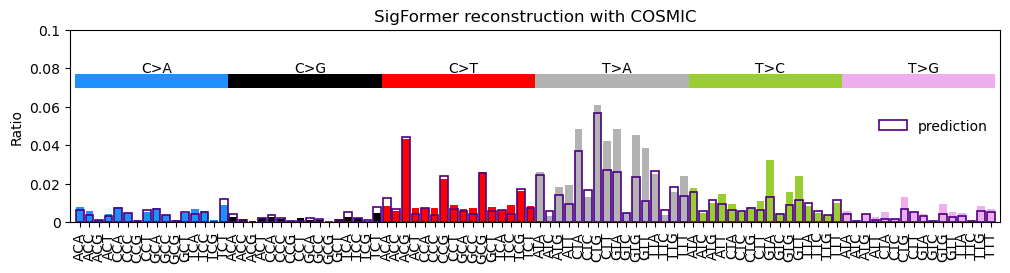

In [22]:
### calc OOC for SigFormer
profile = analysis.sum_scale(X_raw_prof)
DICT_res["SigFormer"]['residuals'] = profile - DICT_res["SigFormer"]['compo'] @ R_cosmic34
residual = DICT_res['SigFormer']['residuals']

### SigFormer reconstruction on these samples
O337 = umap_meta.index[umap_meta.index.astype(str).str.contains('O337')]
pos = analysis.sum_scale(residual.loc[O337].clip(lower=0))
raw_average = pd.DataFrame(profile.loc[O337].mean()).T
ax, maxy = analysis.PLOT_3nt_patterns(raw_average, mode_numb='ratio', title=f'SigFormer reconstruction with COSMIC')
analysis.PLOT_pred_outline(pd.DataFrame(DICT_res['SigFormer']['recon'].loc[O337].mean()).T, ax, maxy, mode_numb='count')
ax.figure.savefig(PATH_cohort__OOC / f'SigFormer_O337_1_raw_reconstruction.pdf')
plt.show() ; plt.close(ax.figure)

ax, maxy = analysis.PLOT_3nt_patterns(pos, mode_plot='mean', mode_numb='ratio', title=f'SigFormer: sample average positive residuals')
ax.figure.savefig(PATH_cohort__OOC / f'SigFormer_O337_2_average_positive_residual.pdf')
plt.show() ; plt.close(ax.figure)

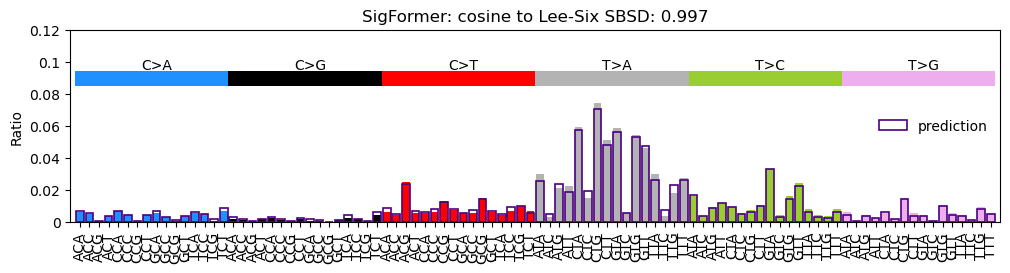

In [32]:
### load external data from LeeSix for SBSD
lee_six = pd.read_csv(PATH_cohort_ext / 'R_LeeSix_de_novo.tsv', sep='\t', index_col=0).reindex(columns=VEC_sub_ctx)

### SigFormer reconstruction on these samples
combined = pos.mean()
combined = combined / combined.sum() * 0.351 + R_cosmic34.loc['SBS1'] * 0.042 + R_cosmic34.loc['SBS25'] * 0.356 + R_cosmic34.loc['SBS22a'] * 0.251
combined = pd.DataFrame(combined).T
cosine = analysis.CALC_cos_sim(combined, lee_six.loc[['SBSD']]).iloc[0, 1]
ax, maxy = analysis.PLOT_3nt_patterns(lee_six.loc[['SBSD']], mode_numb='ratio', title=f'SigFormer: cosine to Lee-Six SBSD: {cosine:.3f}')
analysis.PLOT_pred_outline(combined, ax, maxy, mode_numb='count')
ax.figure.savefig(PATH_cohort__OOC / f'SigFormer_O337_3_reconstruction_SBSD.pdf')
plt.show() ; plt.close(ax.figure)

---

## 7. Per-cluster positive residuals and cosine heatmap

In [35]:
labels

C0                   C0 | Blood/SBS19
C1                    C1 | Liver/SBS8
C2                   C2 | Colon/SBS88
C3                   C3 | Colon/SBS18
C4.blood       C4.blood | Blood/SBS19
C4.other            C4.other | Spleen
C5                         C5 | Colon
C6.breast    C6.breast | Breast/SBS92
C6.other       C6.other | Liver/SBS92
C7                   C7 | Liver/SBS92
C8                    C8 | Blood/SBS3
C9                    C9 | Blood/SBS9
dtype: object

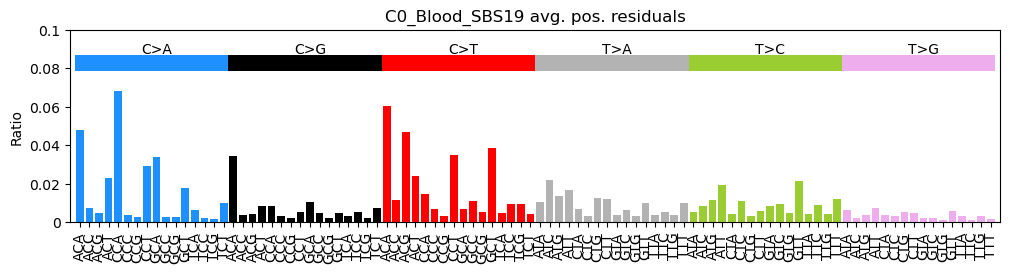

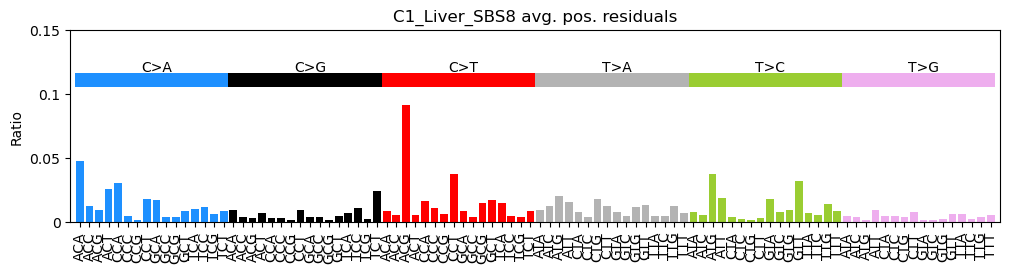

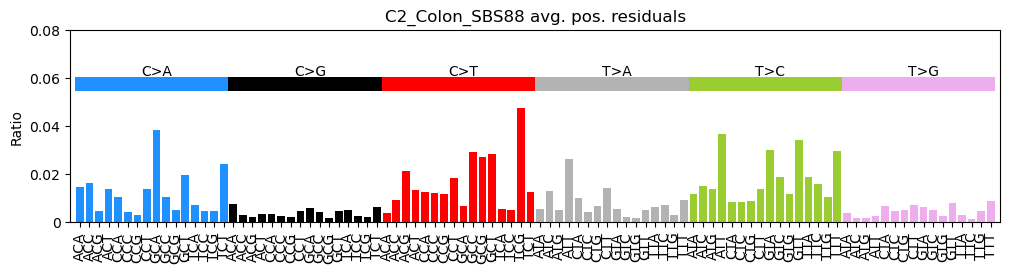

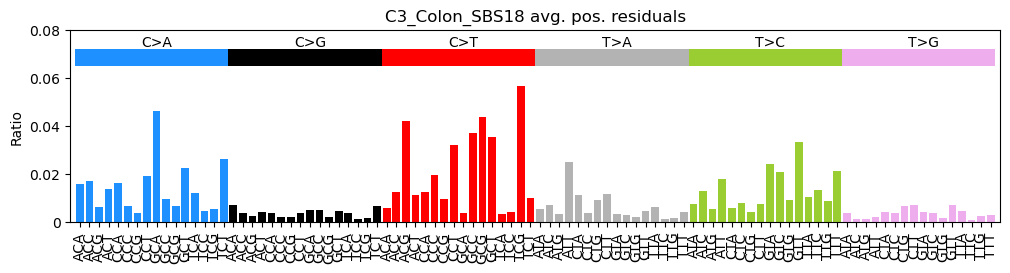

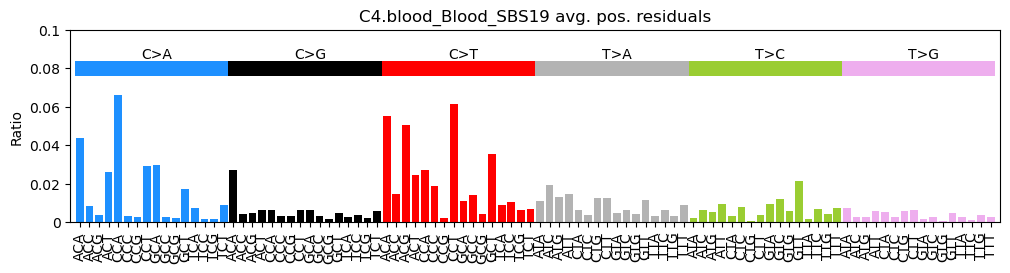

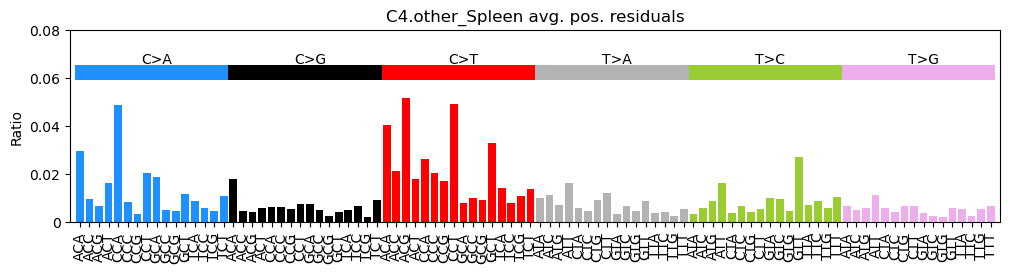

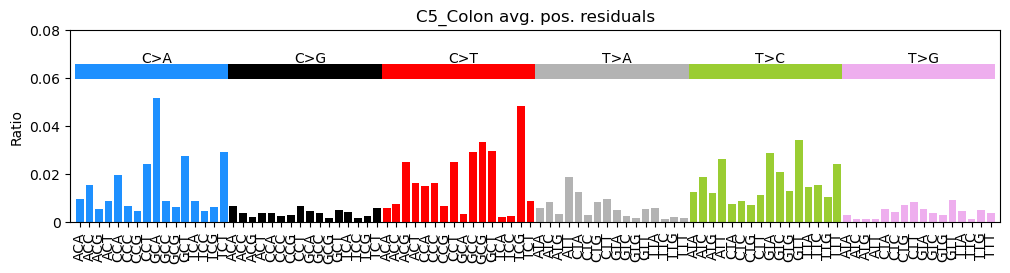

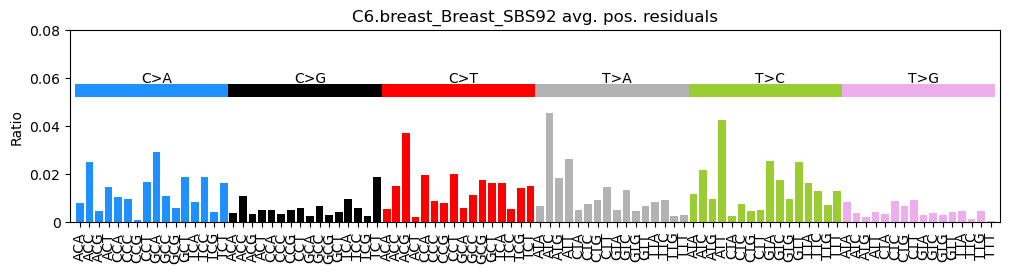

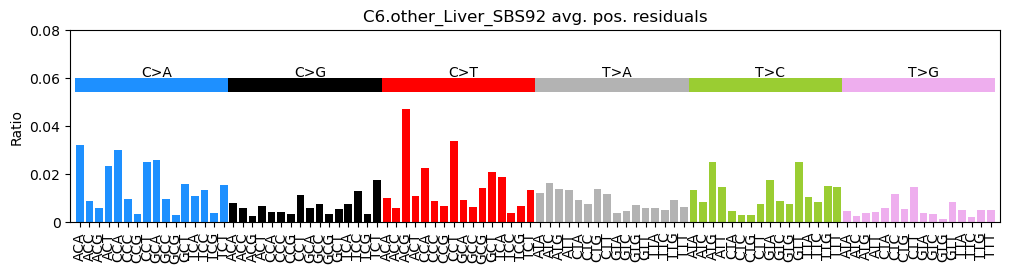

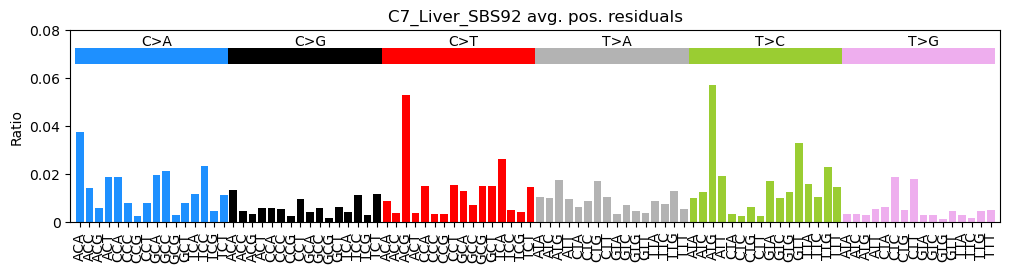

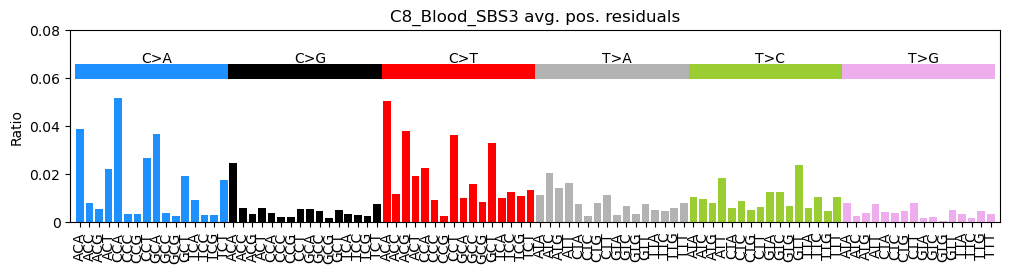

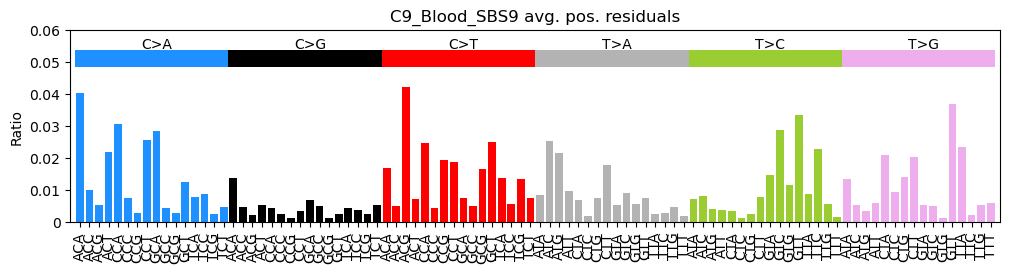

In [39]:
# Aggregate positive residuals by cluster and render the cosine-similarity heatmap.

RESIDUAL_CONFIG = {
    'tissue_col': 'tissue',
    'background_sigs': ('SBS1', 'SBS5', 'SBS40a'),
    'tissue_split_cutoff': 0.6,
    'distinct_cosine_cutoff': 0.85,
    'distinct_excess_cutoff': 0.05,
    'signature_label_cutoff': 0.03,
    'label_mode': 'compact',
}
aggregate, similarity, records, labels, order = analysis.residual_cluster_summary(DICT_res['SigFormer']['compo'], DICT_res['SigFormer']['residuals'], umap_meta, formal_cluster_col, **RESIDUAL_CONFIG)
for cls in aggregate.index:
    row = aggregate.loc[cls]
    lbl = labels[cls].replace(" | ", "_").replace("/", "_")
    ax, maxy = analysis.PLOT_3nt_patterns(pd.DataFrame([row], index=[cls]), mode_plot='mean', mode_numb='ratio', title=f'{lbl} avg. pos. residuals')
    ax.figure.savefig(PATH_cohort__OOC / f"SigFormer_{lbl}_average_positive_residual.pdf")
    plt.show() ; plt.close(ax.figure)

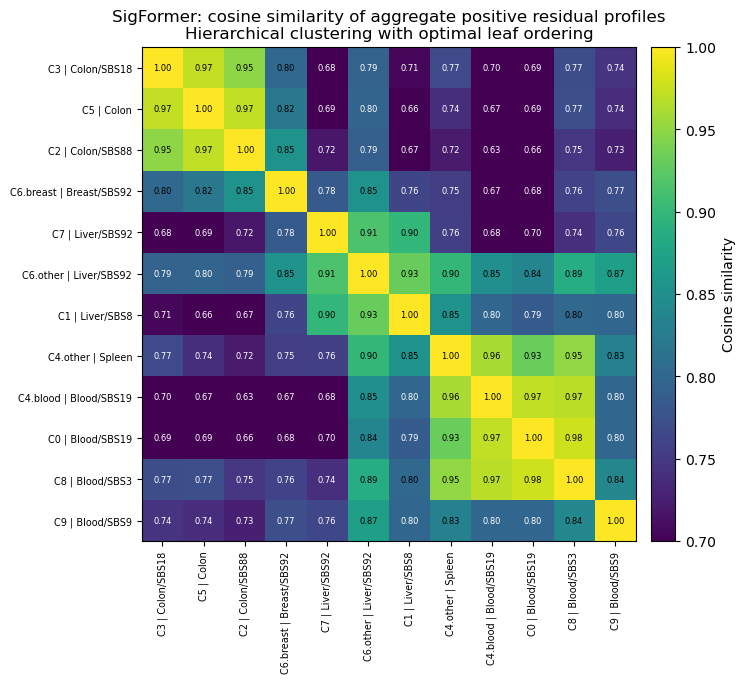

In [40]:
n = len(similarity)
fig, ax = plt.subplots(figsize=(max(7.2, 0.62 * n), max(6.4, 0.56 * n)), constrained_layout=True)
mesh = ax.pcolormesh(np.arange(n + 1), np.arange(n + 1), similarity.to_numpy(float), cmap='viridis', vmin=0.7, vmax=1.0, shading='flat', edgecolors='none', linewidth=0, antialiased=False, snap=True, rasterized=False)
ax.set_xlim(0, n)
ax.set_ylim(n, 0)
ax.set_xticks(np.arange(n) + 0.5)
ax.set_yticks(np.arange(n) + 0.5)
ax.set_xticklabels([labels[x] for x in similarity.index], rotation=90, ha='right', va='center', rotation_mode='anchor', fontsize=7)
ax.set_yticklabels([labels[x] for x in similarity.index], fontsize=7)
ax.set_aspect('equal')

for i in range(n):
    for j in range(n):
        value = similarity.iloc[i, j]
        ax.text(j + 0.5, i + 0.5, f'{value:.2f}', ha='center', va='center', fontsize=6, color='white' if value < 0.8 else 'black')

ax.set_title('SigFormer: cosine similarity of aggregate positive residual profiles\nHierarchical clustering with optimal leaf ordering')
colorbar = fig.colorbar(mesh, ax=ax, fraction=0.045, pad=0.025)
colorbar.set_label('Cosine similarity')
fig.savefig(PATH_cohort__OOC / 'SigFormer_cluster_residual_cosine_heatmap_OLO.pdf')
plt.show() ; plt.close(fig)
aggregate.to_csv(PATH_cohort__OOC / 'SigFormer_per_cluster_positive_residual_profiles.tsv', sep='\t')
similarity.to_csv(PATH_cohort__OOC / 'SigFormer_cluster_residual_cosine_matrix_ordered.tsv', sep='\t')
records.to_csv(PATH_cohort__OOC / 'SigFormer_cluster_labels.tsv', sep='\t', index=False)